# Sliced Wasserstein-2 matching

Random unit directions $\theta_k = g_k/\|g_k\|_2$, $g_k\sim\mathcal{N}(0,I)$, then order-statistic matching:

$$W_2^2(k)=\frac{1}{n}\sum_i (a_{(i)}^{(k)}-b_{(i)}^{(k)})^2,\qquad
\mathrm{SWD}_2=\Big[\frac{1}{K}\sum_{k=1}^K W_2^2(k)\Big]^{1/2}$$

$K=128$. Smaller SWD = closer distributions.

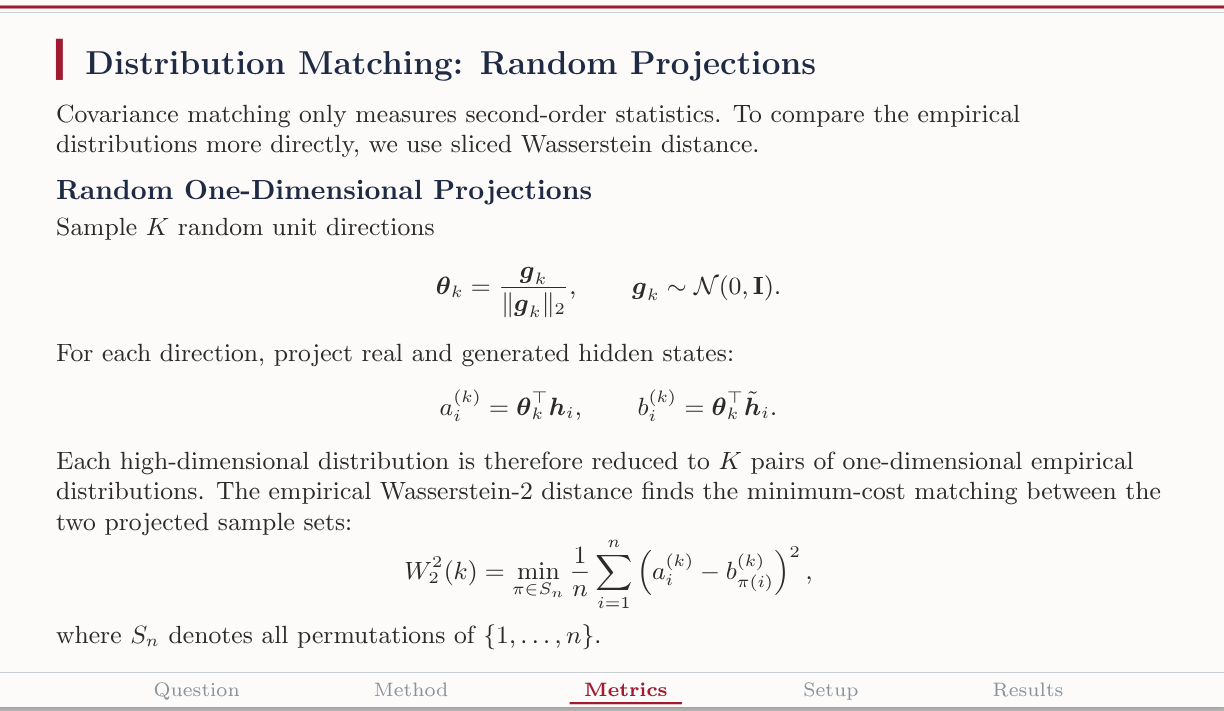

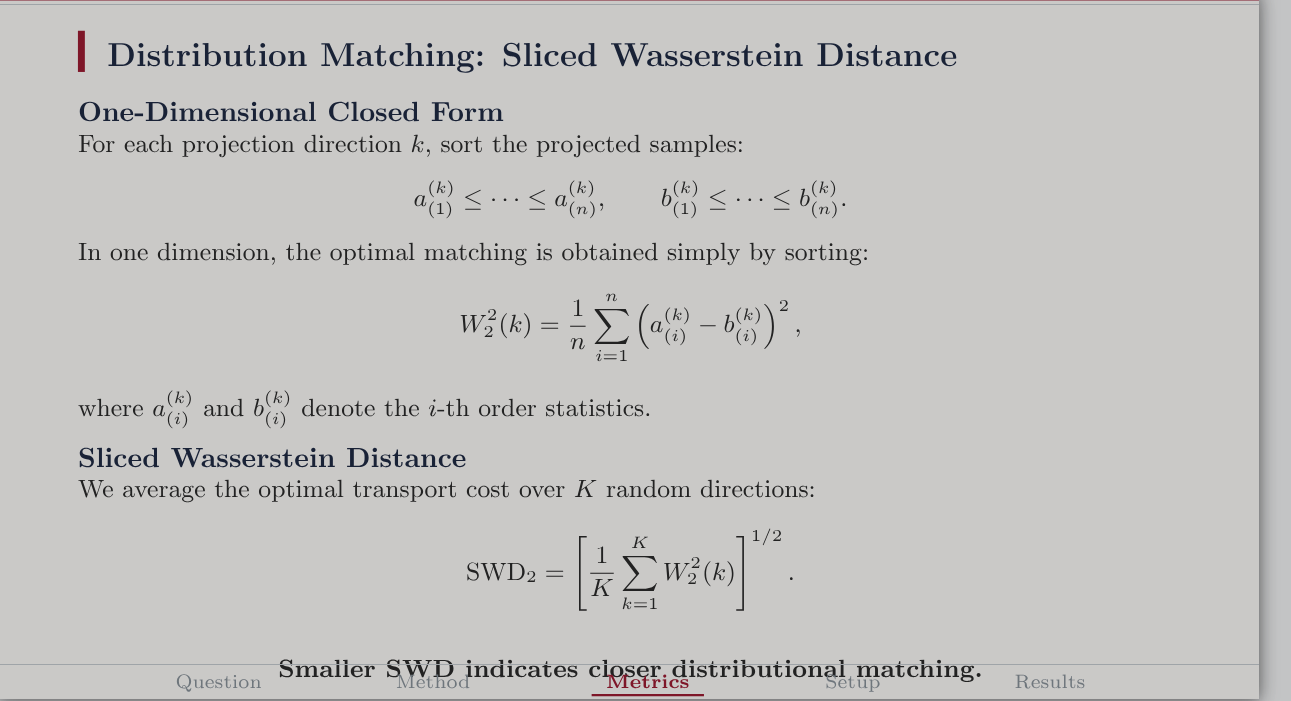

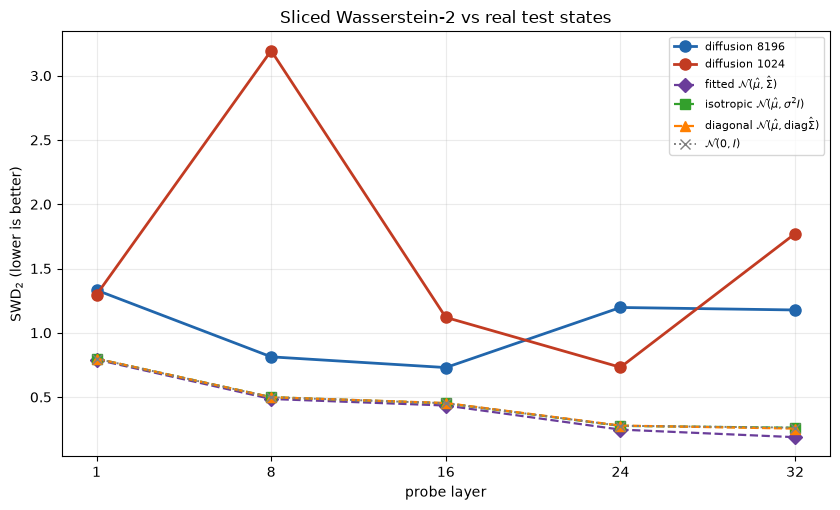

layer     1024     8196   fitted      iso     diag   N(0,I)
    1    1.296    1.332    0.791    0.799    0.799    0.799
    8    3.195    0.813    0.485    0.499    0.499    0.499
   16    1.120    0.730    0.434    0.452    0.454    0.452
   24    0.732    1.197    0.247    0.276    0.278    0.277
   32    1.771    1.178    0.188    0.261    0.255    0.262


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

ROOT = Path.cwd() if (Path.cwd() / "runs").exists() else Path.cwd().parent
FIGS = ROOT / "notebooks" / "figs"
LAYERS = [1, 8, 16, 24, 32]
geom = json.loads((FIGS / "geom_metrics.json").read_text())
x = np.arange(len(LAYERS))

STYLE = {
    "8196": dict(color="#2166ac", marker="o", lw=2.0, ms=8, label=r"diffusion 8196"),
    "1024": dict(color="#c23b22", marker="o", lw=2.0, ms=8, label=r"diffusion 1024"),
    "fitted": dict(color="#6a3d9a", marker="D", lw=1.6, ms=7, ls="--",
                   label=r"fitted $\mathcal{N}(\hat\mu,\hat\Sigma)$"),
    "isotropic": dict(color="#33a02c", marker="s", lw=1.6, ms=7, ls="--",
                      label=r"isotropic $\mathcal{N}(\hat\mu,\sigma^2 I)$"),
    "diagonal": dict(color="#ff7f00", marker="^", lw=1.6, ms=7, ls="--",
                     label=r"diagonal $\mathcal{N}(\hat\mu,\mathrm{diag}\hat\Sigma)$"),
    "n01": dict(color="#7f7f7f", marker="x", lw=1.4, ms=7, ls=":",
                label=r"$\mathcal{N}(0,I)$"),
}

def series(key):
    if key in ("1024", "8196"):
        return [geom["layers"][str(l)]["diffusion"][key] for l in LAYERS]
    return [geom["layers"][str(l)]["baselines"][key] for l in LAYERS]

def plot_metric(ax, metric, ylabel, title, logy=False):
    for key, st in STYLE.items():
        ys = [row[metric] for row in series(key)]
        ax.plot(x, ys, **st)
    ax.set_xticks(x, [str(l) for l in LAYERS])
    ax.set_xlabel("probe layer")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    if logy:
        ax.set_yscale("log")

display(Image(filename=str(FIGS / "slide_swd_projections.png")))
display(Image(filename=str(FIGS / "slide_swd_closed_form.png")))

fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_metric(ax, "swd", r"$\mathrm{SWD}_2$ (lower is better)",
            "Sliced Wasserstein-2 vs real test states")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(FIGS / "swd.png", dpi=160)
fig.savefig(FIGS / "swd.pdf")
fig.savefig(ROOT / "notebooks" / "swd.pdf")
plt.show()

print(f"{'layer':>5} {'1024':>8} {'8196':>8} {'fitted':>8} {'iso':>8} {'diag':>8} {'N(0,I)':>8}")
for l in LAYERS:
    a = geom["layers"][str(l)]
    print(f"{l:>5} {a['diffusion']['1024']['swd']:>8.3f} {a['diffusion']['8196']['swd']:>8.3f} "
          f"{a['baselines']['fitted']['swd']:>8.3f} {a['baselines']['isotropic']['swd']:>8.3f} "
          f"{a['baselines']['diagonal']['swd']:>8.3f} {a['baselines']['n01']['swd']:>8.3f}")
